# MSCS 634 – Project Deliverable 1
## Data Collection, Cleaning, and Exploration

**Student Name:** Nishan Pathak

**Course:** Advanced Big Data and Data Mining  

**Deliverable:** 1  

### Project Objective
The goal of this deliverable is to select a suitable dataset, clean and preprocess the data, perform exploratory data analysis (EDA), and identify initial insights that will guide future modeling steps.


## Dataset Description

The dataset used in this project is the **Customer Personality Analysis dataset**, which contains information about customer demographics and purchasing behavior.

The dataset includes 2240 records and 29 attributes describing customer characteristics such as age, income, education level, marital status, purchasing behavior, and responses to marketing campaigns.

Key attributes in the dataset include:

- **Year_Birth** – Customer's birth year
- **Income** – Customer annual income
- **Education** – Education level of the customer
- **Marital_Status** – Marital status of the customer
- **Kidhome / Teenhome** – Number of children or teenagers in the household
- **MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts** – Amount spent on different product categories
- **NumWebPurchases, NumStorePurchases, NumCatalogPurchases** – Number of purchases made through different channels
- **AcceptedCmp1–AcceptedCmp5** – Whether the customer accepted previous marketing campaigns
- **Response** – Whether the customer responded to the latest marketing campaign

This dataset is appropriate for this project because it contains sufficient records and multiple attributes that allow for meaningful analysis, predictive modeling, and customer behavior insights.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [3]:
url = "https://raw.githubusercontent.com/digvijay-m-s/Customer-Personality-Analysis/main/marketing_campaign.csv"
df = pd.read_csv(url, sep="\t")

df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.shape


(2240, 29)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
df.describe()


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [7]:
df.isnull().sum()


,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [10]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [11]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [16]:
df['Age'] = 2026 - df['Year_Birth']

The dataset contains the customer's birth year (Year_Birth). To make the data easier to analyze, a new feature Age was created by subtracting the birth year from the current year (2026). This derived feature helps in understanding the age distribution of customers and allows better analysis of customer demographics

In [17]:
df[['Year_Birth','Age']].head()

,Year_Birth,Age
0,1957,69
1,1954,72
2,1965,61
3,1984,42
4,1981,45


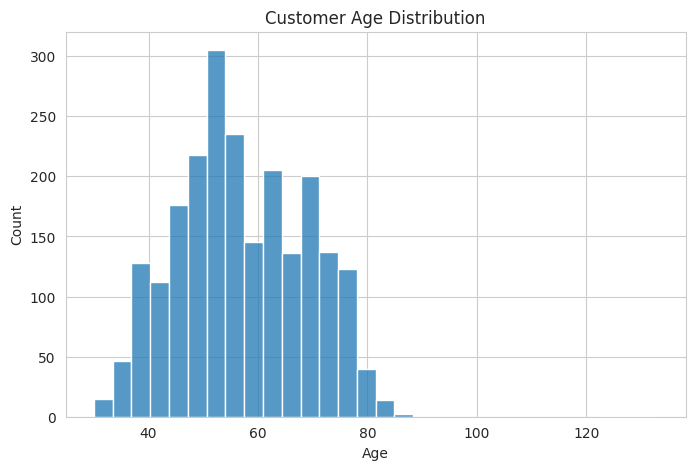

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### Age Distribution Insight

The histogram shows that most customers are between 40 and 70 years old.
The highest concentration of customers appears around the 50–60 age range.
This indicates that the company's primary customer base consists of middle-aged individuals.

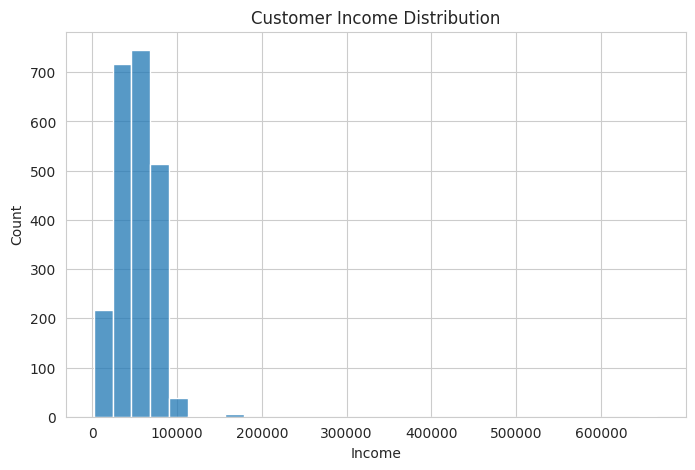

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['Income'], bins=30)
plt.title("Customer Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

### Income Distribution Insight

The income distribution is right-skewed, meaning most customers earn moderate incomes between \$20,000 and \$90,000. A small number of customers have significantly higher incomes, which may
represent high-value or premium customers.

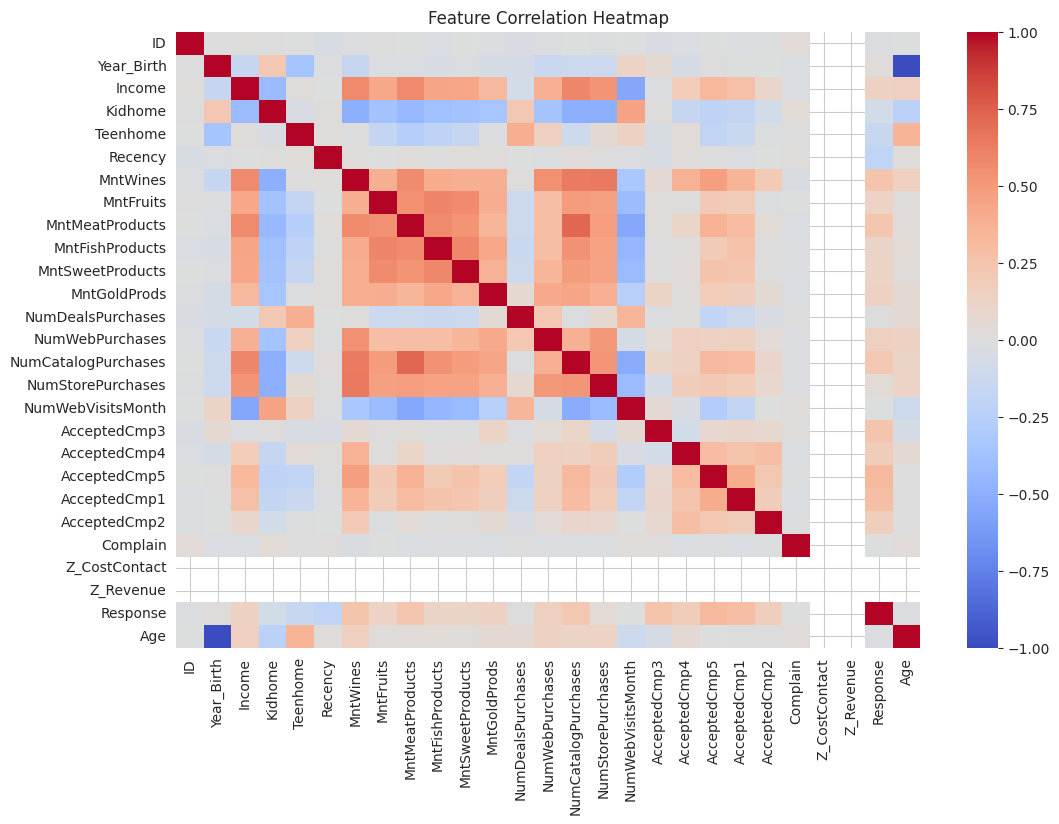

In [22]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

### Correlation Analysis

The correlation heatmap reveals relationships between numerical variables in the dataset.

Key observations include:

- Spending variables such as **MntWines, MntFruits, MntMeatProducts, MntFishProducts, and MntSweetProducts** show positive correlations with each other. This suggests that customers who spend more in one category often spend more in other product categories as well.

- **Income** shows a positive relationship with several spending features, indicating that customers with higher income tend to spend more on products.

- **NumWebPurchases, NumCatalogPurchases, and NumStorePurchases** also show correlations with spending variables, suggesting that higher purchasing activity is associated with higher product spending.

- **Age** does not show strong correlations with most spending variables, indicating that purchasing behavior may depend more on income and purchasing habits than age alone.

These insights will help guide feature selection and modeling decisions in later stages of the project.


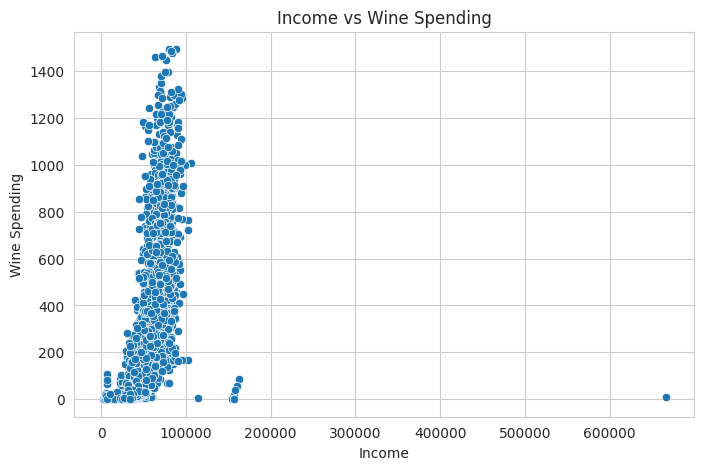

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Income', y='MntWines', data=df)
plt.title("Income vs Wine Spending")
plt.xlabel("Income")
plt.ylabel("Wine Spending")
plt.show()

### Income vs Wine Spending

The scatter plot shows a positive relationship between income and wine spending.
Customers with higher income generally spend more on wine products.
Most customers fall within the \$20,000–\$100,000 income range.
A few customers with extremely high income appear as outliers but represent a very small portion of the dataset.


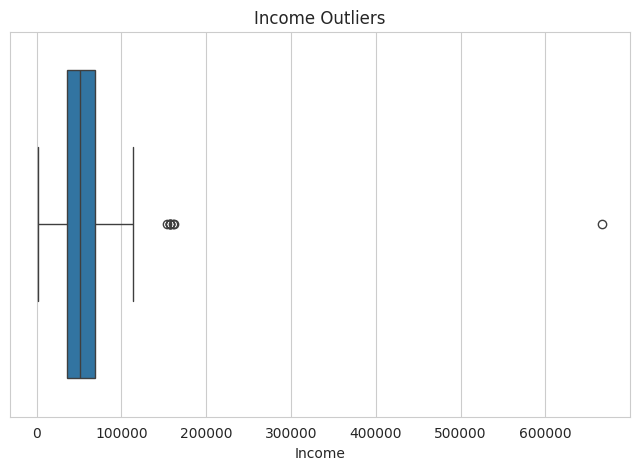

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Income'])
plt.title("Income Outliers")
plt.show()

### Income Outlier Analysis

The boxplot reveals that most customers earn between \$20,000 and \$90,000 annually. However, several high-income outliers are present, including one extremely large income value above $600,000.
These outliers may influence statistical analysis and predictive models and should be considered carefully in later modeling stages.


## Key Insights from Exploratory Data Analysis

The exploratory data analysis revealed several important patterns in the dataset:

1. The majority of customers are middle-aged, mostly between 40 and 70 years old.
2. Customer income distribution is right-skewed, with most customers earning between \$20,000 and \$90,000.
3. Income shows a positive relationship with product spending, especially wine purchases.
4. Spending variables across different product categories are positively correlated.
5. Some extreme income values were detected, indicating potential outliers that may influence modeling results.

These insights help identify important features and relationships that will guide feature engineering and predictive modeling in the next stages of the project.
